In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import kagglehub
import os
path = kagglehub.dataset_download("zafarali27/house-price-prediction-dataset")
print("Path to dataset files:", path)

print(os.listdir(path))

Path to dataset files: C:\Users\User\.cache\kagglehub\datasets\zafarali27\house-price-prediction-dataset\versions\1
['House Price Prediction Dataset.csv']


In [7]:
df = pd.read_csv(path + "/House Price Prediction Dataset.csv")
print(df.shape)
print(df.head())
print(df.dtypes)

(2000, 10)
   Id  Area  Bedrooms  Bathrooms  Floors  YearBuilt  Location  Condition  \
0   1  1360         5          4       3       1970  Downtown  Excellent   
1   2  4272         5          4       3       1958  Downtown  Excellent   
2   3  3592         2          2       3       1938  Downtown       Good   
3   4   966         4          2       2       1902  Suburban       Fair   
4   5  4926         1          4       2       1975  Downtown       Fair   

  Garage   Price  
0     No  149919  
1     No  424998  
2     No  266746  
3    Yes  244020  
4    Yes  636056  
Id            int64
Area          int64
Bedrooms      int64
Bathrooms     int64
Floors        int64
YearBuilt     int64
Location     object
Condition    object
Garage       object
Price         int64
dtype: object


In [ ]:
cat_cols = df.select_dtypes(include="object").columns.tolist()
num_cols = df.select_dtypes(include=np.number).columns.tolist()
print("Categorical:", cat_cols)
print("Numerical:", num_cols)

# 3. One-hot encode categorical columns
df_encoded = pd.get_dummies(df, columns=cat_cols, drop_first=True)

Categorical: ['Location', 'Condition', 'Garage']
Numerical: ['Id', 'Area', 'Bedrooms', 'Bathrooms', 'Floors', 'YearBuilt', 'Price']


In [10]:
X = df_encoded.drop("Price", axis=1)
y = df_encoded["Price"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [ ]:
lin_model = LinearRegression()
lin_model.fit(X_train_scaled, y_train)
lin_preds = lin_model.predict(X_test_scaled)
gb_model = GradientBoostingRegressor(n_estimators=200, learning_rate=0.05, random_state=42)
gb_model.fit(X_train, y_train)
gb_preds = gb_model.predict(X_test)

In [12]:
for name, preds in [("Linear Regression", lin_preds), ("Gradient Boosting", gb_preds)]:
    mae = mean_absolute_error(y_test, preds)
    rmse = np.sqrt(mean_squared_error(y_test, preds))
    r2 = r2_score(y_test, preds)
    print(f"\n--- {name} ---")
    print(f"MAE:  {mae:,.2f}")
    print(f"RMSE: {rmse:,.2f}")
    print(f"R²:   {r2:.3f}")


--- Linear Regression ---
MAE:  242,867.45
RMSE: 279,785.21
R²:   -0.006

--- Gradient Boosting ---
MAE:  245,853.66
RMSE: 285,043.45
R²:   -0.044


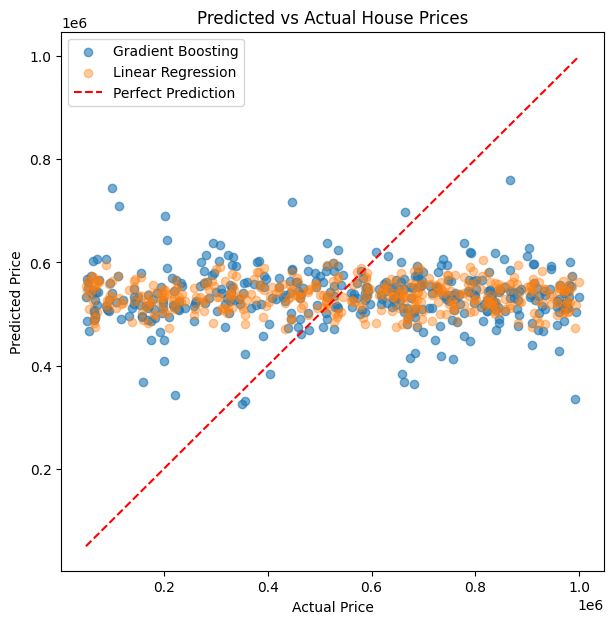

In [13]:
plt.figure(figsize=(7, 7))
plt.scatter(y_test, gb_preds, alpha=0.6, label="Gradient Boosting")
plt.scatter(y_test, lin_preds, alpha=0.4, label="Linear Regression")
plt.plot([y.min(), y.max()], [y.min(), y.max()], "r--", label="Perfect Prediction")
plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("Predicted vs Actual House Prices")
plt.legend()
plt.show()

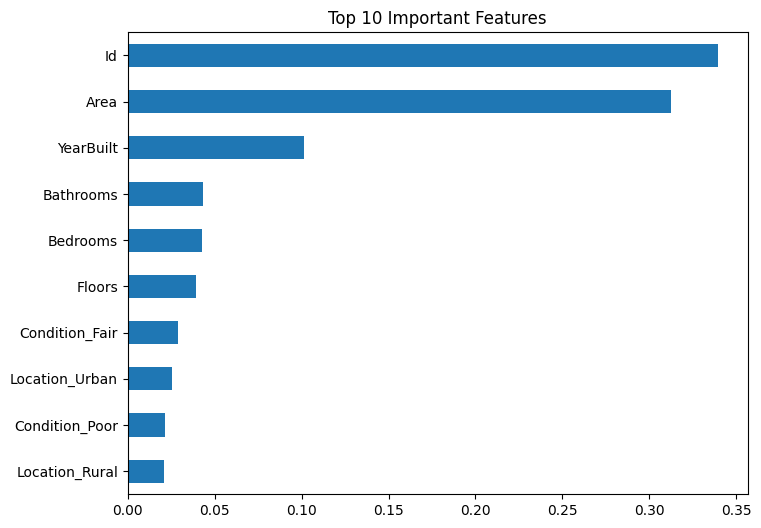

In [14]:
importance = pd.Series(gb_model.feature_importances_, index=X.columns)
importance.sort_values(ascending=False).head(10).plot(kind="barh", figsize=(8, 6))
plt.title("Top 10 Important Features")
plt.gca().invert_yaxis()
plt.show()